## Przeprowadzenie kalibracji i wyznaczenie mapy rewej i prawej tylko dla obrazów dla których chccemy wyznaczyć mapę głębi

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_parameters_for_2_cameras():
    # Termination criteria
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    calibration_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW

    # Inner size of chessboard
    width = 9
    height = 6
    square_size = 0.025  # 0.025 meters

    # Prepare object points
    objp = np.zeros((height * width, 1, 3), np.float64)
    objp[:, 0, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)
    objp = objp * square_size  # Create real-world coordinates

    # Arrays to store object points and image points
  # 3D points in real-world space
    objpoints = []  # 3D points in real-world space
    imgpoints_right = []  # 2D points in image plane
    imgpoints_left = []  # 2D points in image plane

    # Image parameters
    img_width = 640
    img_height = 480
    image_size = (img_width, img_height)

    # Image directory
    path = ""
    image_dir = path + "pairs/"
    number_of_images = 50

    # Process images
    for i in range(1, number_of_images):
        # Read image
        img_right = cv2.imread(image_dir + "right" + "_%02d.png" % i)
        img_left = cv2.imread(image_dir + "left" + "_%02d.png" % i)

        gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)
        gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
        # Find the chessboard corners
        ret_right, corners_right = cv2.findChessboardCorners(
            gray_right, (width, height),
            cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE
        )
        ret_left, corners_left = cv2.findChessboardCorners(
            gray_left, (width, height),
            cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE
        )
        # Skip images where corners are too close to edges
        Y, X, channels = img_left.shape
        if ret_left and ret_right:
            minRx_l = corners_left[:, :, 0].min()
            maxRx_l = corners_left[:, :, 0].max()
            minRy_l = corners_left[:, :, 1].min()
            maxRy_l = corners_left[:, :, 1].max()
            border_threshold_x_l = X / 12
            border_threshold_y_l = Y / 12
            x_thresh_bad_l = minRx_l < border_threshold_x_l
            y_thresh_bad_l = minRy_l < border_threshold_y_l

            minRx_r = corners_right[:, :, 0].min()
            maxRx_r = corners_right[:, :, 0].max()
            minRy_r = corners_right[:, :, 1].min()
            maxRy_r = corners_right[:, :, 1].max()
            border_threshold_x_r = X / 12
            border_threshold_y_r = Y / 12
            x_thresh_bad_r = minRx_r < border_threshold_x_r
            y_thresh_bad_r = minRy_r < border_threshold_y_r
            if x_thresh_bad_r or y_thresh_bad_r or x_thresh_bad_l or y_thresh_bad_l:
                continue

            # Add object points and refine image points
            objpoints.append(objp)

            corners2_l = cv2.cornerSubPix(gray_left, corners_left, (3, 3), (-1, -1), criteria)
            imgpoints_left.append(corners2_l)

            corners2_r = cv2.cornerSubPix(gray_right, corners_right, (3, 3), (-1, -1), criteria)
            imgpoints_right.append(corners2_r)

            # Draw and display the corners
            cv2.drawChessboardCorners(img_left, (width, height), corners2_l, ret_left)
            cv2.imshow("Corners", img_left)
            cv2.waitKey(5)

            cv2.drawChessboardCorners(img_right, (width, height), corners2_r, ret_right)
            cv2.imshow("Corners", img_right)
            cv2.waitKey(5)
        else:
            print("Chessboard couldn’t be detected. Image pair:", i)
            
    N_OK = len(objpoints)
    K_left = np.zeros((3, 3))
    D_left = np.zeros((4, 1))
    rvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]
    tvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]

    ret_left, K_left, D_left, _, _ = cv2.fisheye.calibrate(
        objpoints, imgpoints_left, image_size, K_left, D_left, rvecs, tvecs,
        calibration_flags,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)
    )

    K_right = np.zeros((3, 3))
    D_right = np.zeros((4, 1))
    rvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]
    tvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]

    ret_right, K_right, D_right, _, _ = cv2.fisheye.calibrate(
        objpoints, imgpoints_right, image_size, K_right, D_right, rvecs, tvecs,
        calibration_flags,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)
    )

    return objpoints, (K_right, D_right, imgpoints_right), (K_left, D_left, imgpoints_left)




In [18]:


def get_maps(objpoints, K_right, D_right, imgpointsRight, K_left, D_left, imgpointsLeft):

    # Rozdzielczość obrazów
    img_width = 640
    img_height = 480
    image_size = (img_width, img_height)  # Upewniamy się, że jest tuplem (int, int)

    # Konwersja punktów na typ float64
    imgpointsLeft = np.asarray(imgpointsLeft, dtype=np.float64)
    imgpointsRight = np.asarray(imgpointsRight, dtype=np.float64)

    # Kalibracja stereo
    (RMS, _, _, _, _, rotationMatrix, translationVector) = cv2.fisheye.stereoCalibrate(
        objpoints, imgpointsLeft, imgpointsRight,
        K_left, D_left,
        K_right, D_right,
        image_size, None, None,
        cv2.CALIB_FIX_INTRINSIC,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.01)
    )

    # Inicjalizacja macierzy wynikowych
    R2 = np.zeros((3, 3))
    P1 = np.zeros((3, 4))
    P2 = np.zeros((3, 4))
    Q = np.zeros((4, 4))

    # Rektyfikacja wyników kalibracji
    (leftRectification, rightRectification, leftProjection, rightProjection, disparityToDepthMap) = cv2.fisheye.stereoRectify(
        K_left, D_left,
        K_right, D_right,
        image_size,
        rotationMatrix, translationVector,
        0, R2 , P1 , P2 , Q ,
        cv2 . CALIB_ZERO_DISPARITY , (0 ,0) , 0 , 0)



    # Tworzenie map do usuwania zniekształceń
    map1_left, map2_left = cv2.fisheye.initUndistortRectifyMap(
        K_left, D_left, leftRectification,
        leftProjection, image_size, cv2.CV_16SC2
    )
    map1_right, map2_right = cv2.fisheye.initUndistortRectifyMap(
        K_right, D_right, rightRectification,
        rightProjection, image_size, cv2.CV_16SC2
    )
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(map1_left[..., 1], cmap='gray')
    plt.title("map1_left")

    plt.subplot(1, 2, 2)
    plt.imshow(map1_right[..., 1], cmap='jet')
    plt.title("map1_right")

    plt.show()
    return map1_left, map2_left, map1_right, map2_right



In [29]:
def get_disparity_map(image_dir, map1_left, map2_left, map1_right, map2_right):
    '''
    Parametry wejśćiwe:
        - image_dir - połączone dwa obrazy w osi x
        - map1_left
        - map2_left
        - map1_right
        - map2_right
    Funckja wyrysowuje obrazy po zastosowaniu na nich operacji wyrłwnywania lini ekwipotencjalnych oraz oblicza mapę głębi BM oraz SGM i je wyrysowuje 
    '''
    example = cv2.imread(image_dir)

    ex_len = int(example.shape[1]/2)
    left_example = example[:, :ex_len, :]
    right_example = example[:, ex_len:, :]
    img_l = cv2.cvtColor(left_example, cv2.COLOR_BGR2GRAY)
    img_r = cv2.cvtColor(right_example, cv2.COLOR_BGR2GRAY)

    img_l = cv2.resize(img_l, (640, 480))
    img_r = cv2.resize(img_r, (640, 480))

    dst_L = cv2 . remap ( img_l , map1_left , map2_left , cv2 . INTER_LINEAR )
    dst_R = cv2 . remap ( img_r , map1_right , map2_right , cv2 . INTER_LINEAR )

    stereo = cv2.StereoBM_create(numDisparities=256, blockSize=21)
    disparity_BM = stereo.compute(dst_L, dst_R)
    disparity_BM = cv2.normalize(disparity_BM, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    disparity_BM = np.uint8(disparity_BM)

    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=16*6,  # Liczba poziomów dysparycji
        blockSize=9,
        P1=8 * 3 * 9**2,  # Regularyzacja
        P2=32 * 3 * 9**2,
        disp12MaxDiff=1,
        uniquenessRatio=15,
        speckleWindowSize=100,
        speckleRange=32
    )
    disparity_SGM = stereo.compute(dst_L, dst_R)
    disparity_SGM = cv2.normalize(disparity_SGM, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    disparity_SGM = np.uint8(disparity_SGM)


    fig, ax = plt.subplots(2, 2, figsize=(10, 10))

    # Liczba linii epipolarnych (np. co 30 pikseli)
    step = 30
    image_height = dst_L.shape[0]

    # Lewy obraz z liniami
    ax[0, 0].imshow(dst_L, cmap='gray')
    for y in range(0, image_height, step):
        ax[0, 0].axhline(y, color='cyan', linestyle='--', linewidth=0.5)
    ax[0, 0].set_title("Left (linie epipolarne)")
    ax[0, 0].axis("off")

    # Prawy obraz z liniami
    ax[0, 1].imshow(dst_R, cmap='gray')
    for y in range(0, image_height, step):
        ax[0, 1].axhline(y, color='cyan', linestyle='--', linewidth=0.5)
    ax[0, 1].set_title("Right (linie epipolarne)")
    ax[0, 1].axis("off")

    # Mapa BM
    ax[1, 0].imshow(disparity_BM, cmap='hot')
    ax[1, 0].set_title("BM")
    ax[1, 0].axis("off")

    # Mapa SGM
    ax[1, 1].imshow(disparity_SGM, cmap='hot')
    ax[1, 1].set_title("SGM")
    ax[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

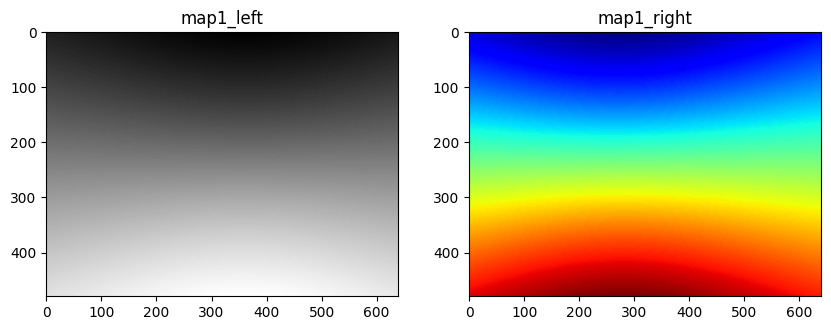

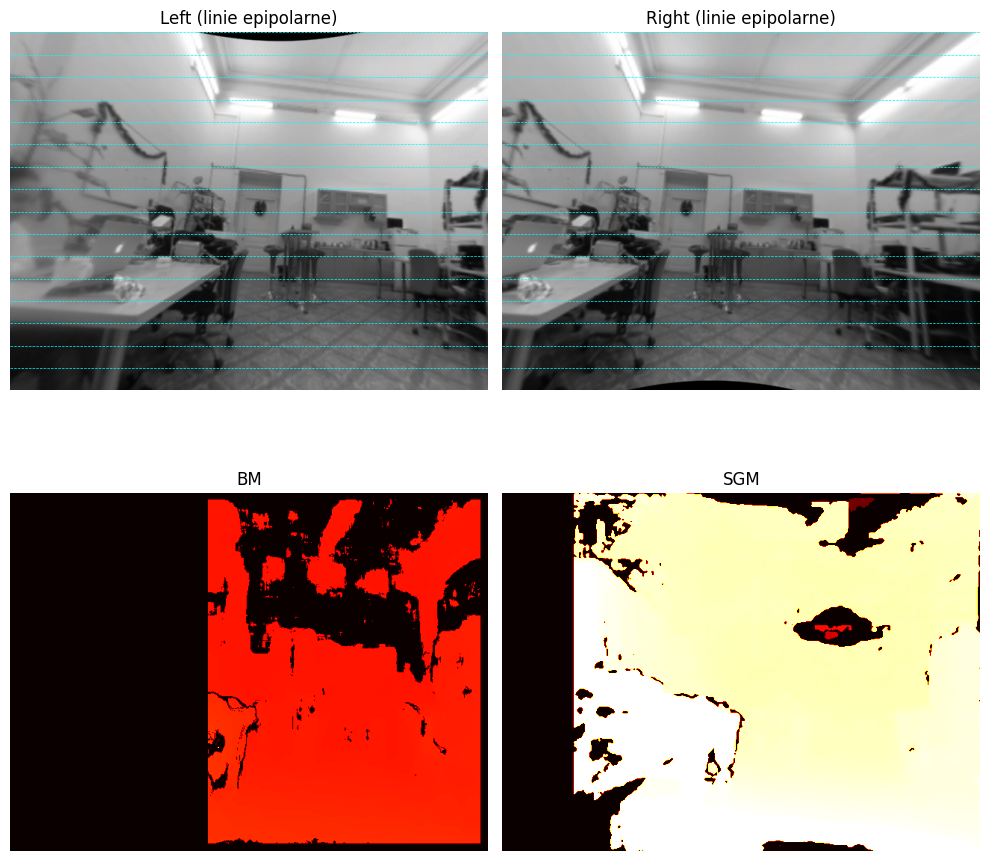

In [30]:

image_dir ="example/example0.jpg" 
example = cv2.imread(image_dir)

objpoints, (K_right, D_right, imgpoints_right), (K_left, D_left, imgpoints_left) = get_parameters_for_2_cameras()

map1_left, map2_left, map1_right, map2_right = get_maps(objpoints, K_right, D_right, imgpoints_right, K_left, D_left, imgpoints_left)

get_disparity_map(image_dir, map1_left, map2_left, map1_right, map2_right)

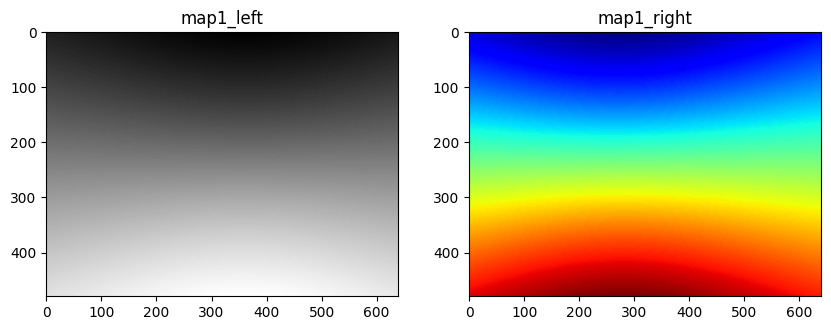

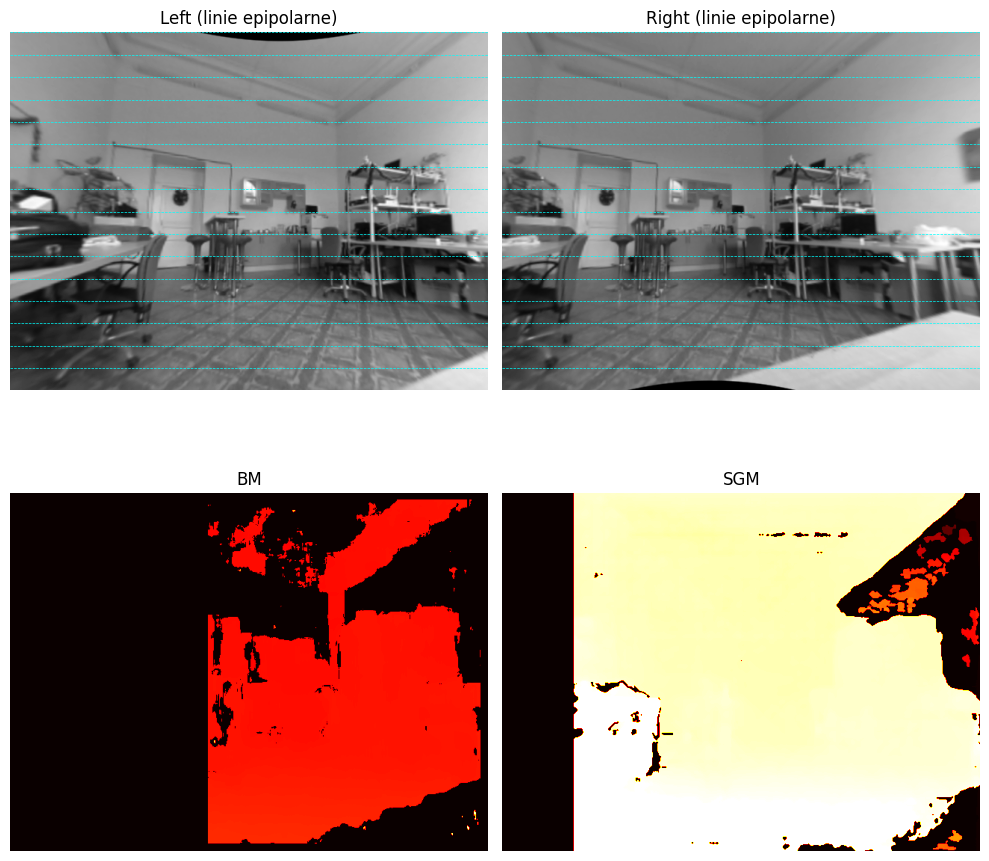

In [22]:

image_dir ="example/example1.png" 
example = cv2.imread(image_dir)

objpoints, (K_right, D_right, imgpoints_right), (K_left, D_left, imgpoints_left) = get_parameters_for_2_cameras()

map1_left, map2_left, map1_right, map2_right = get_maps(objpoints, K_right, D_right, imgpoints_right, K_left, D_left, imgpoints_left)

get_disparity_map(image_dir, map1_left, map2_left, map1_right, map2_right)

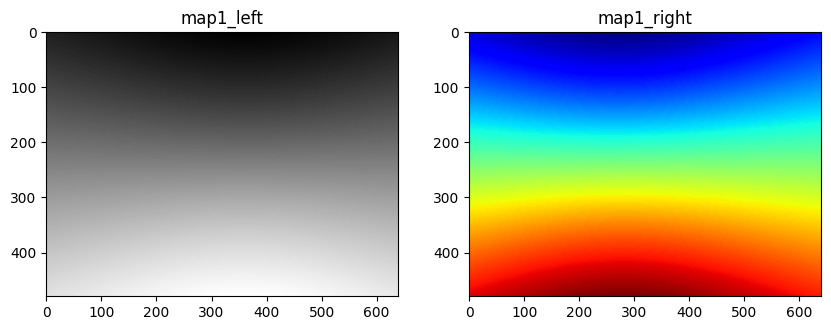

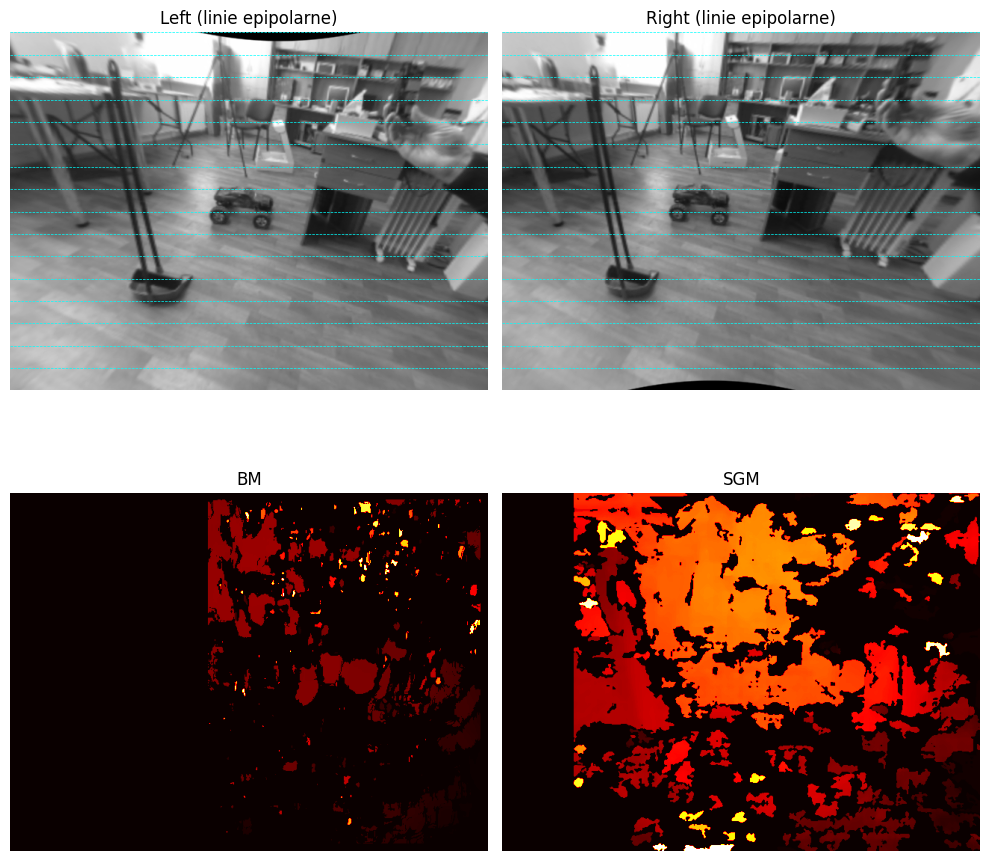

In [23]:

image_dir ="example/example2.jpg" 
example = cv2.imread(image_dir)

objpoints, (K_right, D_right, imgpoints_right), (K_left, D_left, imgpoints_left) = get_parameters_for_2_cameras()

map1_left, map2_left, map1_right, map2_right = get_maps(objpoints, K_right, D_right, imgpoints_right, K_left, D_left, imgpoints_left)

get_disparity_map(image_dir, map1_left, map2_left, map1_right, map2_right)